In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da

import matplotlib.pyplot as plt

import os
from glob import glob
from swot import browse_swot_250m, browse_swot_2km, add_grid_metrics,rotate_ggd
from cstes import swot_dir_2km, zarr_dir

In [2]:
# Stencil method
def apply_stencil_diff(image, var, dx, dy):
    from scipy.ndimage import convolve
    assert var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'], "var must be in 'dx', 'dy', 'dxx', 'dyy', 'dxy'"
    
    stx = np.array([[1/280, -4/105, 1/5, 4/5, 0, -4/5, -1/5, 4/105, -1/280]])
    sty = stx.T

    if var == 'dx' : output = convolve(image, stx)/dx
    if var == 'dy' : output = convolve(image, sty)/dy
    if var == 'dxx' : output = convolve(convolve(image, stx), stx)/dx/dx
    if var == 'dyy' : output = convolve(convolve(image, sty), sty)/dy/dy
    if var == 'dxy' : output = convolve(convolve(image, stx), sty)/dy/dx
    
    return xr.DataArray(output, dims=image.dims)


# Fitting kernel
def fitting_coeff(image, var, dx, dy): 
    """
    var must be in 'cste', 'dx', 'dy', 'dxx', 'dyy', 'dxy'
    """
    meaning_coeff = {'cste':0, 'dx':1, 'dy':2, 'dxx':3, 'dyy':4, 'dxy':5}
    assert var in meaning_coeff.keys(), "var must be in 'cste', 'dx', 'dy', 'dxx', 'dyy', 'dxy'"
    n=int(np.sqrt(image.shape[0]))
    if isinstance(image, xr.DataArray): image = image.values
    x = np.arange(n)
    y = np.arange(n)
    X, Y = np.meshgrid(x, y, copy=False)
    X, Y = np.meshgrid(x, y, copy=False)

    X = X.flatten()
    Y = Y.flatten()

    A = np.array([X*0+1, X, Y, X**2, Y**2, X*Y]).T

    coeff, r, rank, s = np.linalg.lstsq(A, image, rcond=-1)
    dxdy_diff = np.array([1, 1/dx, 1/dy, 1/dx/dx, 1/dy/dy, 1/dy/dx]).T
    coeff = coeff*dxdy_diff
    
    return coeff[meaning_coeff[var]]

def apply_fitting_kernel(swot_image, var, npts,dx, dy):
    from scipy.ndimage import generic_filter
    assert npts%2 ==1, 'must be odd'
    return xr.DataArray(generic_filter(swot_image, fitting_coeff, size=[npts, npts], extra_keywords = {'var':var, 'dx':dx, 'dy':dy}), dims=swot_image.dims)

# Gaussian
def apply_gaussian_filter(swot_image, cutoff, mask, dx, dy):
    from scipy.ndimage import convolve1d
    import scipy.signal.windows as wdw
    
    # Gaussian a la mano
    lambda_cutoff = cutoff/dx
    sigma_cutoff = lambda_cutoff * np.sqrt(np.log(2))
    Mg = int(2 * np.round(4*lambda_cutoff)+1)
    gaussian = wdw.gaussian(Mg, std = sigma_cutoff)
    fg= xr.DataArray(convolve1d(convolve1d(swot_image.fillna(0), gaussian, axis=0), gaussian, axis=1), dims=swot_image.dims)#unnromalized
    fm = xr.DataArray(convolve1d(convolve1d(mask, gaussian, axis=0), gaussian, axis=1), dims=mask.dims)#unnormalized
    return xr.DataArray(fg/fm, dims=swot_image.dims)#normalized

# Wraper
def define_eta(ds):
    ds['etaf'] = ds.duacs_ssha_karin_2_filtered + ds.cvl_mean_dynamic_topography_cnes_cls_22 + ds.cvl_ocean_tide_fes_2022
    ds['etac'] = ds.duacs_ssha_karin_2_calibrated + ds.cvl_mean_dynamic_topography_cnes_cls_22 + ds.cvl_ocean_tide_fes_2022

def filter_diff_one(f, filter_diff_method = 'gaussian', filter_diff_kwargs = {'cutoff': 5e3}):
    vars_ = ['etaf', 'etac','duacs_editing_flag', 'longitude', 'latitude']
    ds = xr.open_dataset(f)
    define_eta(ds)
    ds = add_grid_metrics(ds)
    dx = float(ds.dx.mean())
    dy = float(ds.dy.mean())
    
    ds =ds.drop_vars(['latitude_nadir','longitude_nadir','dx','phi','dy'])[vars_]
    
    #sds = ds.interpolate_na('num_pixels').interpolate_na('num_lines') # erreur dans l'entre-fauchée ! (pour gaussian filter at least)
    mask = ds.duacs_editing_flag.where(ds.duacs_editing_flag!=0,1).where(ds.duacs_editing_flag==0,0)
    try : 
        D = []
        for eta in ['etaf', 'etac'] :
            swot_image = ds[eta]
            #gaussian method
            if filter_diff_method == 'gaussian' :
                assert list(filter_diff_kwargs.keys()) == ['cutoff'], 'The gaussian method needs one argument cutoff (gaussian x at H/2)'
                output = apply_gaussian_filter(swot_image,  **filter_diff_kwargs, mask = mask, dx=dx, dy=dy).rename('filtered_'+eta).to_dataset()
                for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                    output[var + '_'+eta] = apply_stencil_diff(output['filtered_'+eta], var, dx=dx, dy=dy)
                D.append(output)
            
            # Fitting kernel method
            if filter_diff_method == 'fitting_kernel' :
                assert list(filter_diff_kwargs.keys()) == ['npts'], 'The fitting kernel method needs one argument npts (odd, kernel = [npts, npts])'
                output = apply_fitting_kernel(swot_image, **filter_diff_kwargs, var = 'cste', dx=dx, dy=dy).rename('filtered_'+eta).to_dataset()
                for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                    output[var + '_'+eta] = apply_fitting_kernel(swot_image, **filter_diff_kwargs, var=var, dx=dx, dy=dy)
                D.append(output)

            #diff only method
            if filter_diff_method == 'diff_only' :
                output = swot_image.rename(eta).to_dataset()
                for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                    output[var + '_'+eta] = apply_stencil_diff(swot_image, var, mask, dx=dx, dy=dy)
                D.append(output)
                
            # xarray simple diff
            if filter_diff_method == 'xarray_diff' :
                output = swot_image.rename(eta).to_dataset()
                output['dx_'+eta] = output[eta].differentiate('num_pixels')/dx
                output['dy_'+eta] = output[eta].differentiate('num_lines')/dy
                output['dxx_'+eta] = output['dx_'+eta].differentiate('num_pixels')/dx
                output['dyy_'+eta] = output['dy_'+eta].differentiate('num_lines')/dy
                output['dxy_'+eta] = output['dx_'+eta].differentiate('num_lines')/dy
                D.append(output)
                
    except: 
        assert False, f
    return xr.merge(D + [ds[['longitude', 'latitude']]]).where(ds.duacs_editing_flag==0)

def _concat(ds, filter_diff_method, filter_diff_kwargs):
    D = []
    for f in ds.file.values :
        D.append(filter_diff_one(f, filter_diff_method , filter_diff_kwargs))
    try : 
        xs = xr.concat(D, dim=ds.cycle_number)
    except : 
        assert False, f
    return xs

def compute_filter_diff(ds, filter_diff_method, filter_diff_kwargs):

    template = _concat(ds.isel(cycle_number = slice(0,2)), filter_diff_method ='gaussian', filter_diff_kwargs={'cutoff':5e3}).compute()
    template = template.isel(cycle_number=0).expand_dims({'cycle_number':ds.cycle_number}).chunk({**ds.chunks, **{'num_pixels':-1, 'num_lines':-1}})
    dims = [ "cycle_number", "num_lines", "num_pixels"]
    template = template.transpose(*dims)

    # actually perform the calculation
    ds_diff = ds.map_blocks(
        _concat,
        kwargs = dict( filter_diff_method =filter_diff_method, filter_diff_kwargs=filter_diff_kwargs),
        template=template,
    )
    return ds_diff


# Gaussian

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


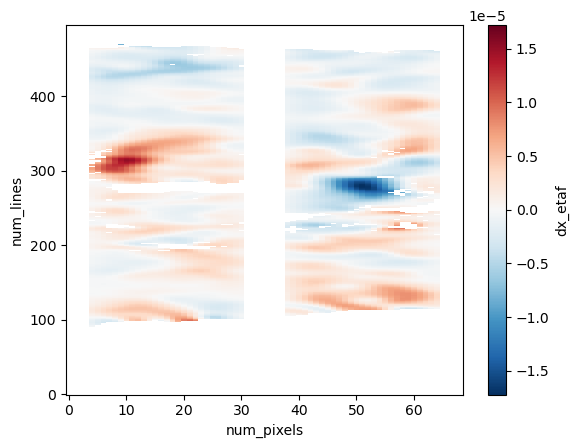

In [3]:
product = 'swot2km'
method = 'gaussian'

if product == 'swot2km':
    dfs = browse_swot_2km().reset_index()

# Gaussian 
from cstes import zarr_dir
pass_=3

df = dfs[dfs.pass_number==pass_]
cutoff = 5000
C = filter_diff_one(df.iloc[0].file, filter_diff_method = method, filter_diff_kwargs = {'cutoff': 5e3})
C.dx_etaf.plot()

# Stencil method 

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


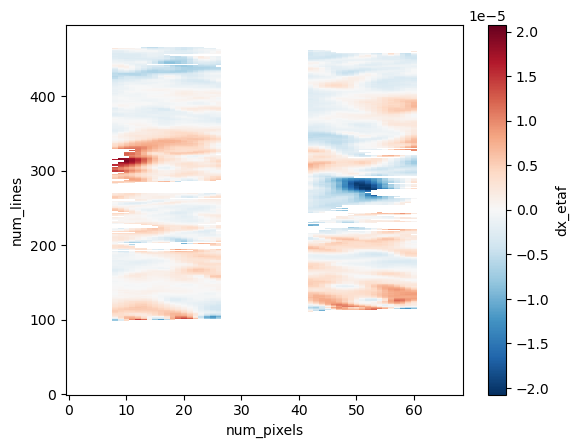

In [10]:
def filter_diff_one(f, filter_diff_method = 'gaussian', filter_diff_kwargs = {'cutoff': 5e3}):
    vars_ = ['etaf', 'etac','duacs_editing_flag', 'longitude', 'latitude']
    ds = xr.open_dataset(f)
    define_eta(ds)
    ds = add_grid_metrics(ds)
    dx = float(ds.dx.mean())
    dy = float(ds.dy.mean())
    
    ds =ds.drop_vars(['latitude_nadir','longitude_nadir','dx','phi','dy'])[vars_]
    

    #ds = ds.interpolate_na('num_pixels').interpolate_na('num_lines') # erreur dans l'entre-fauchée ! (pour gaussian filter at least)
    mask = ds.duacs_editing_flag.where(ds.duacs_editing_flag!=0,1).where(ds.duacs_editing_flag==0,0)
    try : 
        D = []
        for eta in ['etaf', 'etac'] :
            swot_image = ds[eta]
            #gaussian method
            if filter_diff_method == 'gaussian' :
                assert list(filter_diff_kwargs.keys()) == ['cutoff'], 'The gaussian method needs one argument cutoff (gaussian x at H/2)'
                output = apply_gaussian_filter(swot_image,  **filter_diff_kwargs, mask = mask, dx=dx, dy=dy).rename('filtered_'+eta).to_dataset()
                for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                    output[var + '_'+eta] = apply_stencil_diff(output['filtered_'+eta], var, dx=dx, dy=dy)
                D.append(output)
            
            # Fitting kernel method
            if filter_diff_method == 'fitting_kernel' :
                assert list(filter_diff_kwargs.keys()) == ['npts'], 'The fitting kernel method needs one argument npts (odd, kernel = [npts, npts])'
                output = apply_fitting_kernel(swot_image, **filter_diff_kwargs, var = 'cste', dx=dx, dy=dy).rename('filtered_'+eta).to_dataset()
                for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                    output[var + '_'+eta] = apply_fitting_kernel(swot_image, **filter_diff_kwargs, var=var, dx=dx, dy=dy)
                D.append(output)

            #diff only method
            if filter_diff_method == 'diff_only' :
                output = swot_image.rename(eta).to_dataset()
                for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                    output[var + '_'+eta] = apply_stencil_diff(swot_image, var, mask, dx=dx, dy=dy)
                D.append(output)
                
            # xarray simple diff
            if filter_diff_method == 'xarray_diff' :
                output = swot_image.rename(eta).to_dataset()
                output['dx_'+eta] = output[eta].differentiate('num_pixels')/dx
                output['dy_'+eta] = output[eta].differentiate('num_lines')/dy
                output['dxx_'+eta] = output['dx_'+eta].differentiate('num_pixels')/dx
                output['dyy_'+eta] = output['dy_'+eta].differentiate('num_lines')/dy
                output['dxy_'+eta] = output['dx_'+eta].differentiate('num_lines')/dy
                D.append(output)
                
    except: 
        assert False, f
    return xr.merge(D + [ds[['longitude', 'latitude']]]).where(ds.duacs_editing_flag==0)  

# Stencil method
def apply_stencil_diff(image, var,mask, dx, dy):
    from scipy.ndimage import convolve
    assert var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'], "var must be in 'dx', 'dy', 'dxx', 'dyy', 'dxy'"
    
    stx = np.array([[1/280, -4/105, 1/5, 4/5, 0, -4/5, -1/5, 4/105, -1/280]])
    sty = stx.T

    if var == 'dx' : output = convolve(image, stx, mode='mirror')/dx
    if var == 'dy' : output = convolve(image, sty, mode='mirror')/dy
    if var == 'dxx' : output = convolve(convolve(image, stx, mode='mirror'), stx)/dx/dx
    if var == 'dyy' : output = convolve(convolve(image, sty, mode='mirror'), sty)/dy/dy
    if var == 'dxy' : output = convolve(convolve(image, stx, mode='mirror'), sty)/dy/dx
    
    return xr.DataArray(output, dims=image.dims)

product = 'swot2km'
method = 'diff_only'
# diff only
from cstes import zarr_dir
pass_=3

df = dfs[dfs.pass_number==pass_]
cutoff = 5000
C1 = filter_diff_one(df.iloc[0].file, filter_diff_method = method, filter_diff_kwargs = {})
C1.dx_etaf.plot()

## Adding mask 

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


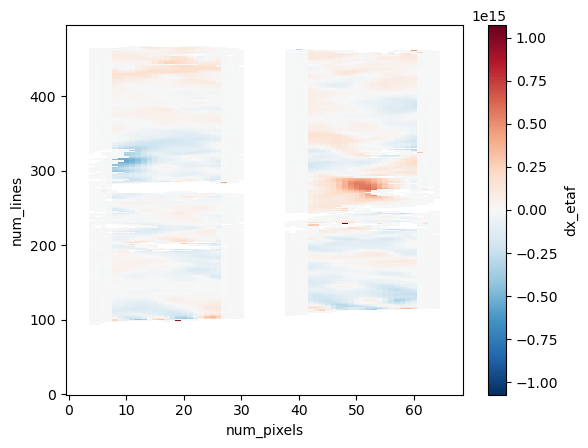

In [5]:
# Stencil method
def apply_stencil_diff(image, var, mask, dx, dy):
    from scipy.ndimage import convolve
    assert var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'], "var must be in 'dx', 'dy', 'dxx', 'dyy', 'dxy'"
    
    stx = np.array([[1/280, -4/105, 1/5,4/5, 0, -4/5,-1/5, 4/105, -1/280]])
    sty = stx.T

    if var == 'dx' : 
        fg = convolve(image.fillna(0), stx)/dx
        fm = convolve(mask, stx)/dx
    if var == 'dy' : 
        fg = convolve(image.fillna(0), sty)/dy
        fm = convolve(mask, sty)/dy
    if var == 'dxx' : 
        fg = convolve(convolve(image.fillna(0), stx), stx)/dx/dx
        fm = convolve(convolve(mask, stx), stx)/dx/dx
    if var == 'dyy' : 
        fg = convolve(convolve(image.fillna(0), sty), sty)/dy/dy
        fm = convolve(convolve(image, sty), sty)/dy/dy
    if var == 'dxy' : 
        fg = convolve(convolve(image.fillna(0), stx), sty)/dy/dx
        fm = convolve(convolve(mask, stx), sty)/dy/dx
    return xr.DataArray(fg, dims=image.dims)/xr.DataArray(fm, dims=image.dims)

product = 'swot2km'
method = 'diff_only'
# Gaussian 
from cstes import zarr_dir
pass_=3

df = dfs[dfs.pass_number==pass_]
cutoff = 5000
C0 = filter_diff_one(df.iloc[0].file, filter_diff_method = method, filter_diff_kwargs = {})
C0.dx_etaf.plot()

## Interp na

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


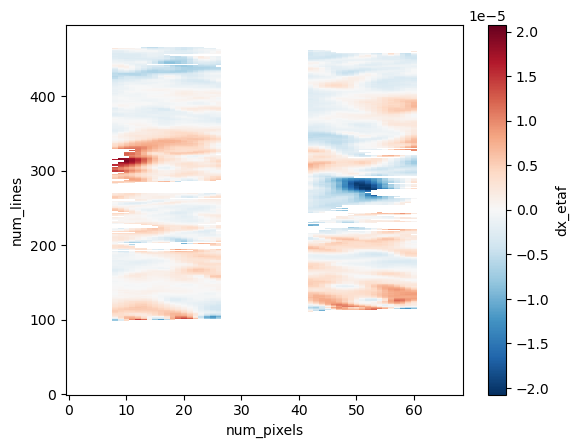

In [6]:
def filter_diff_one(f, filter_diff_method = 'gaussian', filter_diff_kwargs = {'cutoff': 5e3}):
    vars_ = ['etaf', 'etac','duacs_editing_flag', 'longitude', 'latitude']
    ds = xr.open_dataset(f)
    define_eta(ds)
    ds = add_grid_metrics(ds)
    dx = float(ds.dx.mean())
    dy = float(ds.dy.mean())
    
    ds =ds.drop_vars(['latitude_nadir','longitude_nadir','dx','phi','dy'])[vars_]
    

    if filter_diff_method == 'fitting_kernel':
        ds = ds.interpolate_na('num_pixels').interpolate_na('num_lines') # erreur dans l'entre-fauchée pour gaussian filter but ok for fitting kernel
    mask = ds.duacs_editing_flag.where(ds.duacs_editing_flag!=0,1).where(ds.duacs_editing_flag==0,0)
    try : 
        D = []
        for eta in ['etaf', 'etac'] :
            swot_image = ds[eta]
            #gaussian method
            if filter_diff_method == 'gaussian' :
                assert list(filter_diff_kwargs.keys()) == ['cutoff'], 'The gaussian method needs one argument cutoff (gaussian x at H/2)'
                output = apply_gaussian_filter(swot_image,  **filter_diff_kwargs, mask = mask, dx=dx, dy=dy).rename('filtered_'+eta).to_dataset()
                for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                    output[var + '_'+eta] = apply_stencil_diff(output['filtered_'+eta], var, dx=dx, dy=dy)
                D.append(output)
            
            # Fitting kernel method
            if filter_diff_method == 'fitting_kernel' :
                assert list(filter_diff_kwargs.keys()) == ['npts'], 'The fitting kernel method needs one argument npts (odd, kernel = [npts, npts])'
                output = apply_fitting_kernel(swot_image, **filter_diff_kwargs, var = 'cste', dx=dx, dy=dy).rename('filtered_'+eta).to_dataset()
                for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                    output[var + '_'+eta] = apply_fitting_kernel(swot_image, **filter_diff_kwargs, var=var, dx=dx, dy=dy)
                D.append(output)

            #diff only method
            if filter_diff_method == 'diff_only' :
                output = swot_image.rename(eta).to_dataset()
                for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                    output[var + '_'+eta] = apply_stencil_diff(swot_image, var, mask, dx=dx, dy=dy)
                D.append(output)
                
            # xarray simple diff
            if filter_diff_method == 'xarray_diff' :
                output = swot_image.rename(eta).to_dataset()
                output['dx_'+eta] = output[eta].differentiate('num_pixels')/dx
                output['dy_'+eta] = output[eta].differentiate('num_lines')/dy
                output['dxx_'+eta] = output['dx_'+eta].differentiate('num_pixels')/dx
                output['dyy_'+eta] = output['dy_'+eta].differentiate('num_lines')/dy
                output['dxy_'+eta] = output['dx_'+eta].differentiate('num_lines')/dy
                D.append(output)
                
    except: 
        assert False, f
    return xr.merge(D + [ds[['longitude', 'latitude']]]).where(ds.duacs_editing_flag==0)  

# Stencil method
def apply_stencil_diff(image, var,mask, dx, dy):
    from scipy.ndimage import convolve
    assert var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'], "var must be in 'dx', 'dy', 'dxx', 'dyy', 'dxy'"
    
    stx = np.array([[1/280, -4/105, 1/5,4/5, 0, -4/5,-1/5, 4/105, -1/280]])
    sty = stx.T

    if var == 'dx' : output = convolve(image, stx)/dx
    if var == 'dy' : output = convolve(image, sty)/dy
    if var == 'dxx' : output = convolve(convolve(image, stx), stx)/dx/dx
    if var == 'dyy' : output = convolve(convolve(image, sty), sty)/dy/dy
    if var == 'dxy' : output = convolve(convolve(image, stx), sty)/dy/dx
    
    return xr.DataArray(output, dims=image.dims)

product = 'swot2km'
method = 'diff_only'
# Gaussian 
from cstes import zarr_dir
pass_=3

df = dfs[dfs.pass_number==pass_]
cutoff = 5000
C2 = filter_diff_one(df.iloc[0].file, filter_diff_method = method, filter_diff_kwargs = {})
C2.dx_etaf.plot()

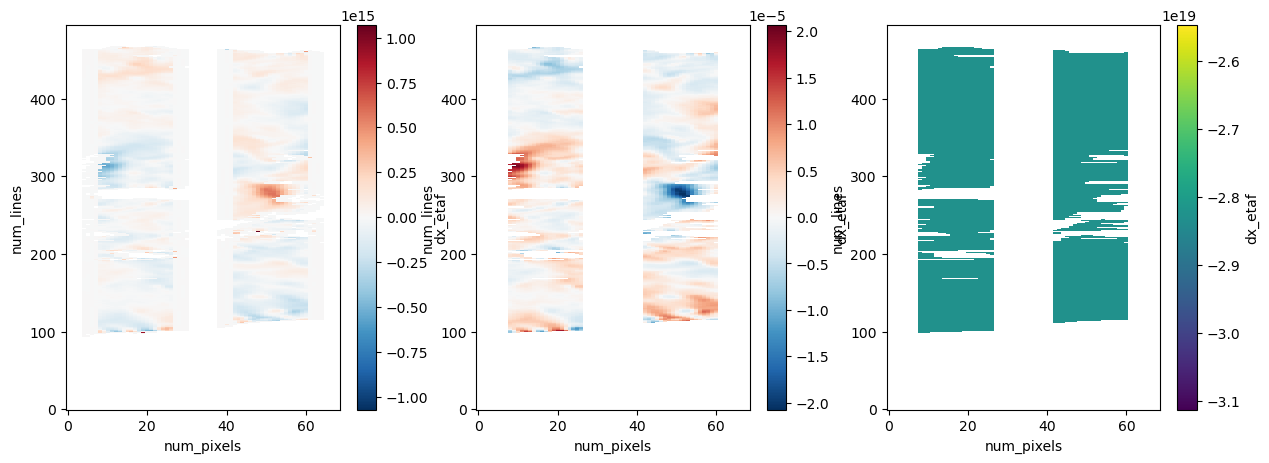

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))

C0.dx_etaf.plot(ax=axs[0])
C1.dx_etaf.plot(ax=axs[1])
(C0/C1).dx_etaf.plot(ax=axs[2])

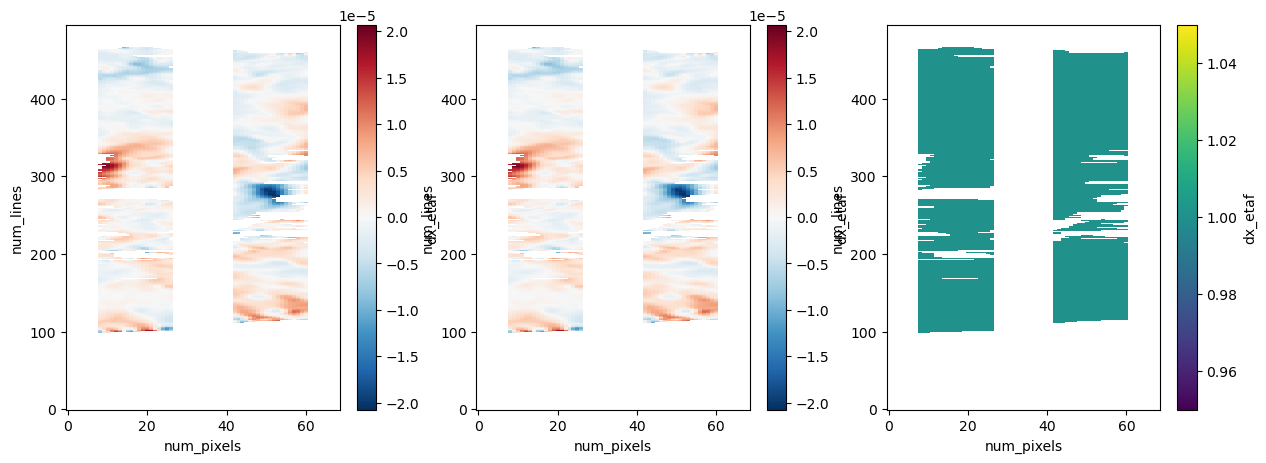

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))

C2.dx_etaf.plot(ax=axs[0])
C1.dx_etaf.plot(ax=axs[1])
(C2/C1).dx_etaf.plot(ax=axs[2], vmin=0.95, vmax=1.05)

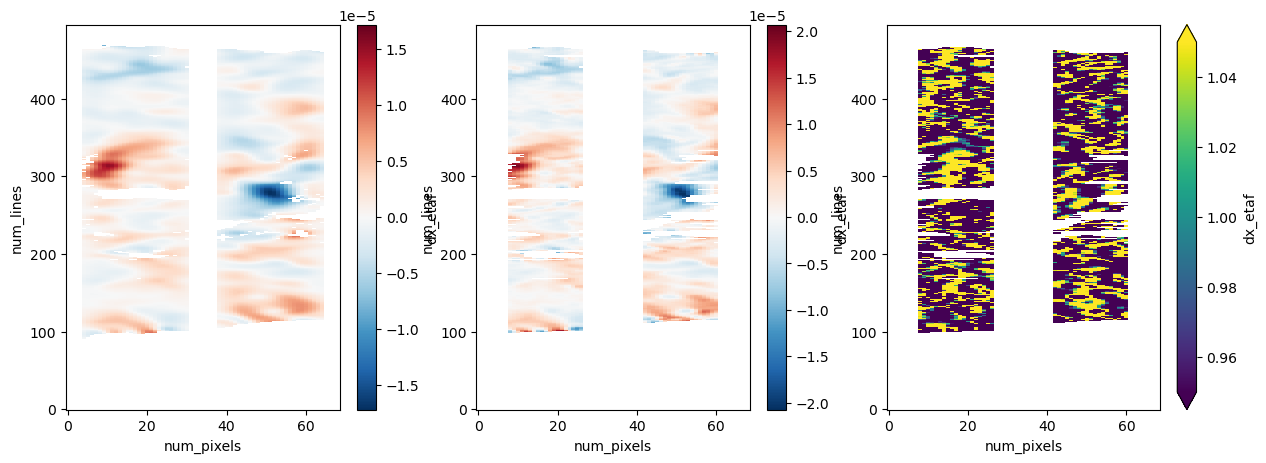

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))

C.dx_etaf.plot(ax=axs[0])
C1.dx_etaf.plot(ax=axs[1])
(C/C1).dx_etaf.plot(ax=axs[2], vmin=0.95, vmax=1.05)

# Fitting kernel

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


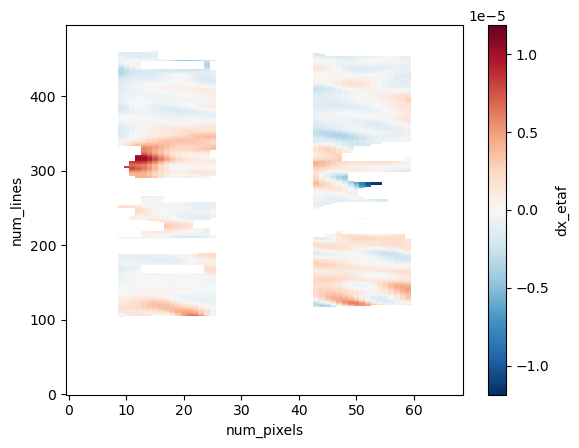

In [57]:
def filter_diff_one(f, filter_diff_method = 'gaussian', filter_diff_kwargs = {'cutoff': 5e3}):
    vars_ = ['etaf', 'etac','duacs_editing_flag', 'longitude', 'latitude']
    ds = xr.open_dataset(f)
    define_eta(ds)
    ds = add_grid_metrics(ds)
    dx = float(ds.dx.mean())
    dy = float(ds.dy.mean())
    
    ds =ds.drop_vars(['latitude_nadir','longitude_nadir','dx','phi','dy'])[vars_]
    

    #ds = ds.interpolate_na('num_pixels').interpolate_na('num_lines') # erreur dans l'entre-fauchée ! (pour gaussian filter at least)
    mask = ds.duacs_editing_flag.where(ds.duacs_editing_flag!=0,1).where(ds.duacs_editing_flag==0,0)
    try : 
        D = []
        for eta in ['etaf', 'etac'] :
            swot_image = ds[eta]
            #gaussian method
            if filter_diff_method == 'gaussian' :
                assert list(filter_diff_kwargs.keys()) == ['cutoff'], 'The gaussian method needs one argument cutoff (gaussian x at H/2)'
                output = apply_gaussian_filter(swot_image,  **filter_diff_kwargs, mask = mask, dx=dx, dy=dy).rename('filtered_'+eta).to_dataset()
                for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                    output[var + '_'+eta] = apply_stencil_diff(output['filtered_'+eta], var, dx=dx, dy=dy)
                D.append(output)
            
            # Fitting kernel method
            if filter_diff_method == 'fitting_kernel' :
                assert list(filter_diff_kwargs.keys()) == ['npts'], 'The fitting kernel method needs one argument npts (odd, kernel = [npts, npts])'
                output = apply_fitting_kernel(swot_image, **filter_diff_kwargs, var = 'cste', dx=dx, dy=dy).rename('filtered_'+eta).to_dataset()
                for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                    output[var + '_'+eta] = apply_fitting_kernel(swot_image, **filter_diff_kwargs, var=var, dx=dx, dy=dy)
                D.append(output)

            #diff only method
            if filter_diff_method == 'diff_only' :
                output = swot_image.rename(eta).to_dataset()
                for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                    output[var + '_'+eta] = apply_stencil_diff(swot_image, var, mask, dx=dx, dy=dy)
                D.append(output)
                
            # xarray simple diff
            if filter_diff_method == 'xarray_diff' :
                output = swot_image.rename(eta).to_dataset()
                output['dx_'+eta] = output[eta].differentiate('num_pixels')/dx
                output['dy_'+eta] = output[eta].differentiate('num_lines')/dy
                output['dxx_'+eta] = output['dx_'+eta].differentiate('num_pixels')/dx
                output['dyy_'+eta] = output['dy_'+eta].differentiate('num_lines')/dy
                output['dxy_'+eta] = output['dx_'+eta].differentiate('num_lines')/dy
                D.append(output)
                
    except: 
        assert False, f
    return xr.merge(D + [ds[['longitude', 'latitude']]]).where(ds.duacs_editing_flag==0)  

product = 'swot2km'
method = 'fitting_kernel' 
from cstes import zarr_dir
pass_=3

df = dfs[dfs.pass_number==pass_]
C0 = filter_diff_one(df.iloc[0].file, filter_diff_method = method, filter_diff_kwargs = {'npts':11})
C0.dx_etaf.plot()

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


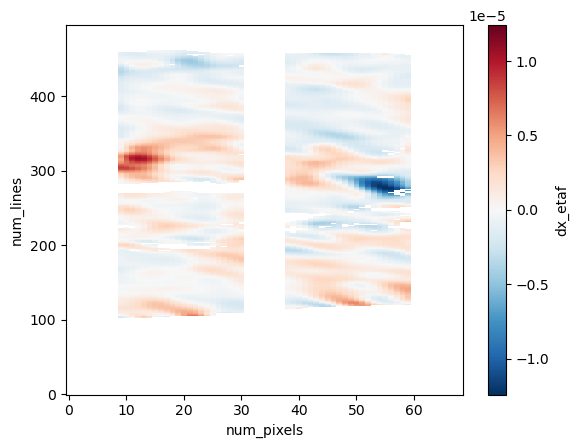

In [58]:
def filter_diff_one(f, filter_diff_method = 'gaussian', filter_diff_kwargs = {'cutoff': 5e3}):
    vars_ = ['etaf', 'etac','duacs_editing_flag', 'longitude', 'latitude']
    ds = xr.open_dataset(f)
    define_eta(ds)
    ds = add_grid_metrics(ds)
    dx = float(ds.dx.mean())
    dy = float(ds.dy.mean())
    
    ds =ds.drop_vars(['latitude_nadir','longitude_nadir','dx','phi','dy'])[vars_]
    

    ds = ds.interpolate_na('num_pixels').interpolate_na('num_lines') # erreur dans l'entre-fauchée ! (pour gaussian filter at least)
    mask = ds.duacs_editing_flag.where(ds.duacs_editing_flag!=0,1).where(ds.duacs_editing_flag==0,0)
    try : 
        D = []
        for eta in ['etaf', 'etac'] :
            swot_image = ds[eta]
            #gaussian method
            if filter_diff_method == 'gaussian' :
                assert list(filter_diff_kwargs.keys()) == ['cutoff'], 'The gaussian method needs one argument cutoff (gaussian x at H/2)'
                output = apply_gaussian_filter(swot_image,  **filter_diff_kwargs, mask = mask, dx=dx, dy=dy).rename('filtered_'+eta).to_dataset()
                for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                    output[var + '_'+eta] = apply_stencil_diff(output['filtered_'+eta], var, dx=dx, dy=dy)
                D.append(output)
            
            # Fitting kernel method
            if filter_diff_method == 'fitting_kernel' :
                assert list(filter_diff_kwargs.keys()) == ['npts'], 'The fitting kernel method needs one argument npts (odd, kernel = [npts, npts])'
                output = apply_fitting_kernel(swot_image, **filter_diff_kwargs, var = 'cste', dx=dx, dy=dy).rename('filtered_'+eta).to_dataset()
                for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                    output[var + '_'+eta] = apply_fitting_kernel(swot_image, **filter_diff_kwargs, var=var, dx=dx, dy=dy)
                D.append(output)

            #diff only method
            if filter_diff_method == 'diff_only' :
                output = swot_image.rename(eta).to_dataset()
                for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                    output[var + '_'+eta] = apply_stencil_diff(swot_image, var, mask, dx=dx, dy=dy)
                D.append(output)
                
            # xarray simple diff
            if filter_diff_method == 'xarray_diff' :
                output = swot_image.rename(eta).to_dataset()
                output['dx_'+eta] = output[eta].differentiate('num_pixels')/dx
                output['dy_'+eta] = output[eta].differentiate('num_lines')/dy
                output['dxx_'+eta] = output['dx_'+eta].differentiate('num_pixels')/dx
                output['dyy_'+eta] = output['dy_'+eta].differentiate('num_lines')/dy
                output['dxy_'+eta] = output['dx_'+eta].differentiate('num_lines')/dy
                D.append(output)
                
    except: 
        assert False, f
    return xr.merge(D + [ds[['longitude', 'latitude']]]).where(ds.duacs_editing_flag==0)  

product = 'swot2km'
method = 'fitting_kernel' 
from cstes import zarr_dir
pass_=3

df = dfs[dfs.pass_number==pass_]
C1 = filter_diff_one(df.iloc[0].file, filter_diff_method = method, filter_diff_kwargs = {'npts':11})
C1.dx_etaf.plot()

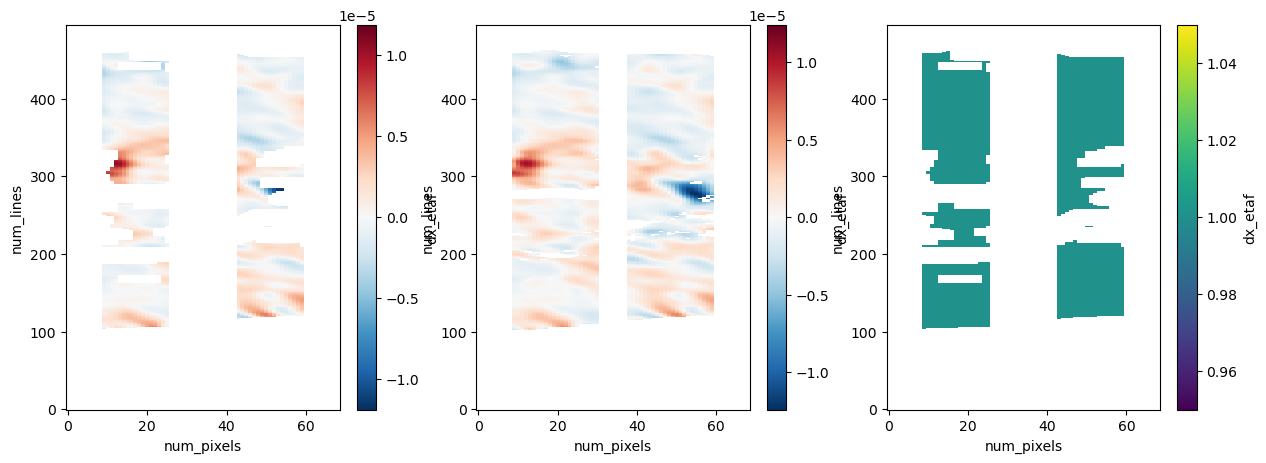

In [62]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))

C0.dx_etaf.plot(ax=axs[0])
C1.dx_etaf.plot(ax=axs[1])
(C0/C1).dx_etaf.plot(ax=axs[2])

In [63]:
(C0/C1).dx_etaf.min()

<xarray.DataArray 'dx_etaf' ()> Size: 8B
array(1.)

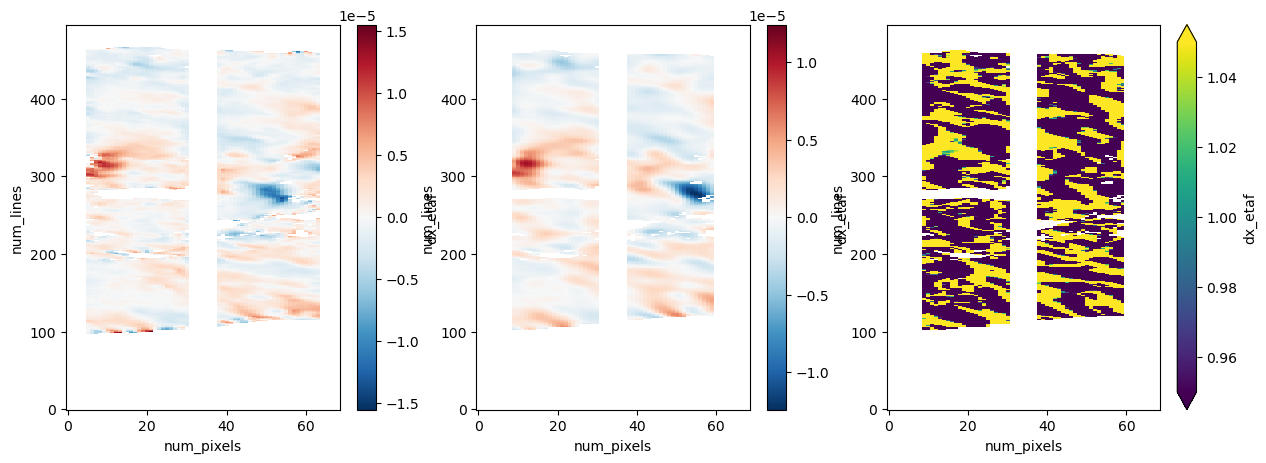

In [64]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))

C2.dx_etaf.plot(ax=axs[0])
C1.dx_etaf.plot(ax=axs[1])
(C2/C1).dx_etaf.plot(ax=axs[2], vmin=0.95, vmax=1.05)

In [66]:
pass_ = 3
cycle= 570

dsd = xr.open_dataset(f'/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/diff_only/{pass_}_{cycle}.nc')/2.1999999999999997
dsx = xr.open_dataset(f'/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/xarray_diff/{pass_}_{cycle}.nc')

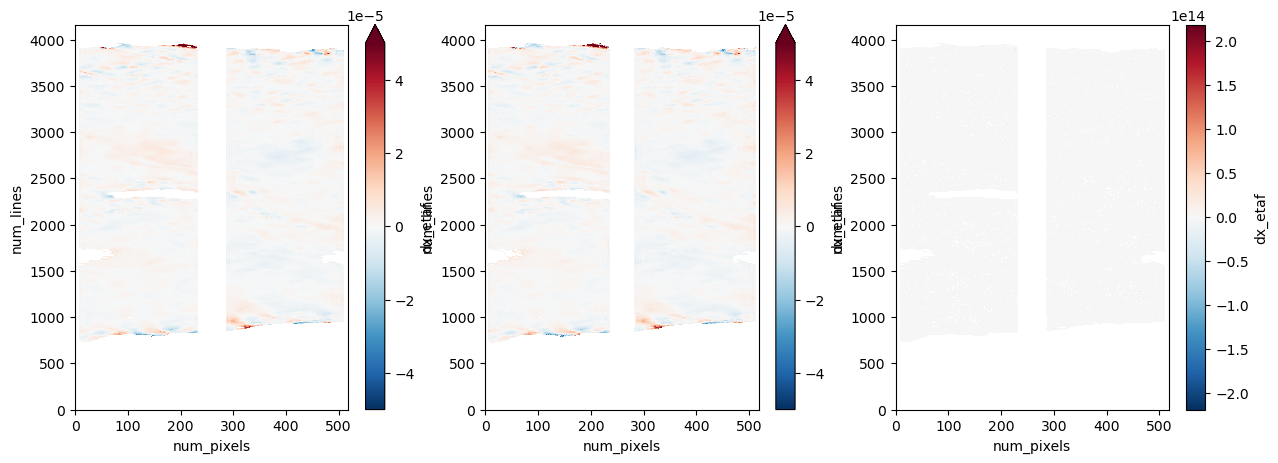

In [67]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))

dsd.dx_etaf.plot(ax=axs[0], vmax=5e-5)
dsx.dx_etaf.plot(ax=axs[1], vmax=5e-5)
(dsd/dsx).dx_etaf.plot(ax=axs[2])

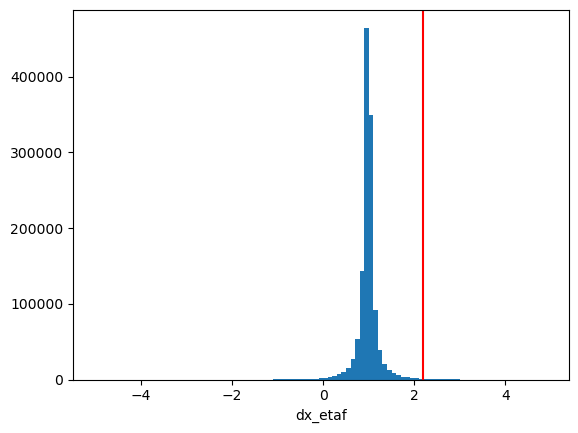

In [68]:
fig, ax = plt.subplots(1,1)

(dsd/dsx).dx_etaf.plot.hist(bins = np.arange(-5, 5, 0.1), ax=ax)
ax.axvline(2.19, c='r')

In [72]:
a = np.arange(0, 9)
#a = np.zeros(9)
b= 4*a
stx = np.array([1/280, -4/105, 1/5, 4/5, 0, -4/5, -1/5, 4/105, -1/280])

In [73]:
sum(np.arange(0, 9)*stx)

-2.1999999999999997

In [70]:
stx = np.array([[1/280, -4/105, 1/5, 4/5, 0, -4/5, -1/5, 4/105, -1/280]])
sty = stx.T
sum(np.arange(0, 9)*sty)

array([ 0.00000000e+00,  7.06899816e-17,  1.41379963e-16, -6.59194921e-17,
        2.82759927e-16,  1.87350135e-16, -1.31838984e-16, -1.97758476e-16,
        5.65519853e-16])